# 建立稳态纯度模型

In [1]:
import os,gzip,pickle
from utils.keys import Cols
import numpy as np
import pandas as pd
import torch
import math
import matplotlib
import matplotlib.pyplot as plt

# 设置字体
matplotlib.rcParams['font.family'] = 'Microsoft YaHei, Times New Roman'
# 全局设置字号
plt.rcParams.update({
    'font.size': 16,  # 基础字号
    'axes.titlesize': 20,  # 标题字号
    'axes.labelsize': 20,  # 坐标轴标签字号
    'xtick.labelsize': 20,  # x轴刻度标签字号
    'ytick.labelsize': 20,  # y轴刻度标签字号
    'legend.fontsize': 16  # 图例字号
})
# 解决负号显示问题
matplotlib.rcParams['axes.unicode_minus'] = False

## 导入数据与数据预处理

In [8]:
with gzip.open(
    r'D:\Devs\Single_Stack_MLJ\data\processed\Test data Hyzenis\2.03-2.05纯度实验\02.03-05气体纯度-60s-1# gzip',
    'rb'
) as f:
    df_Hyzenis = pickle.load(f)

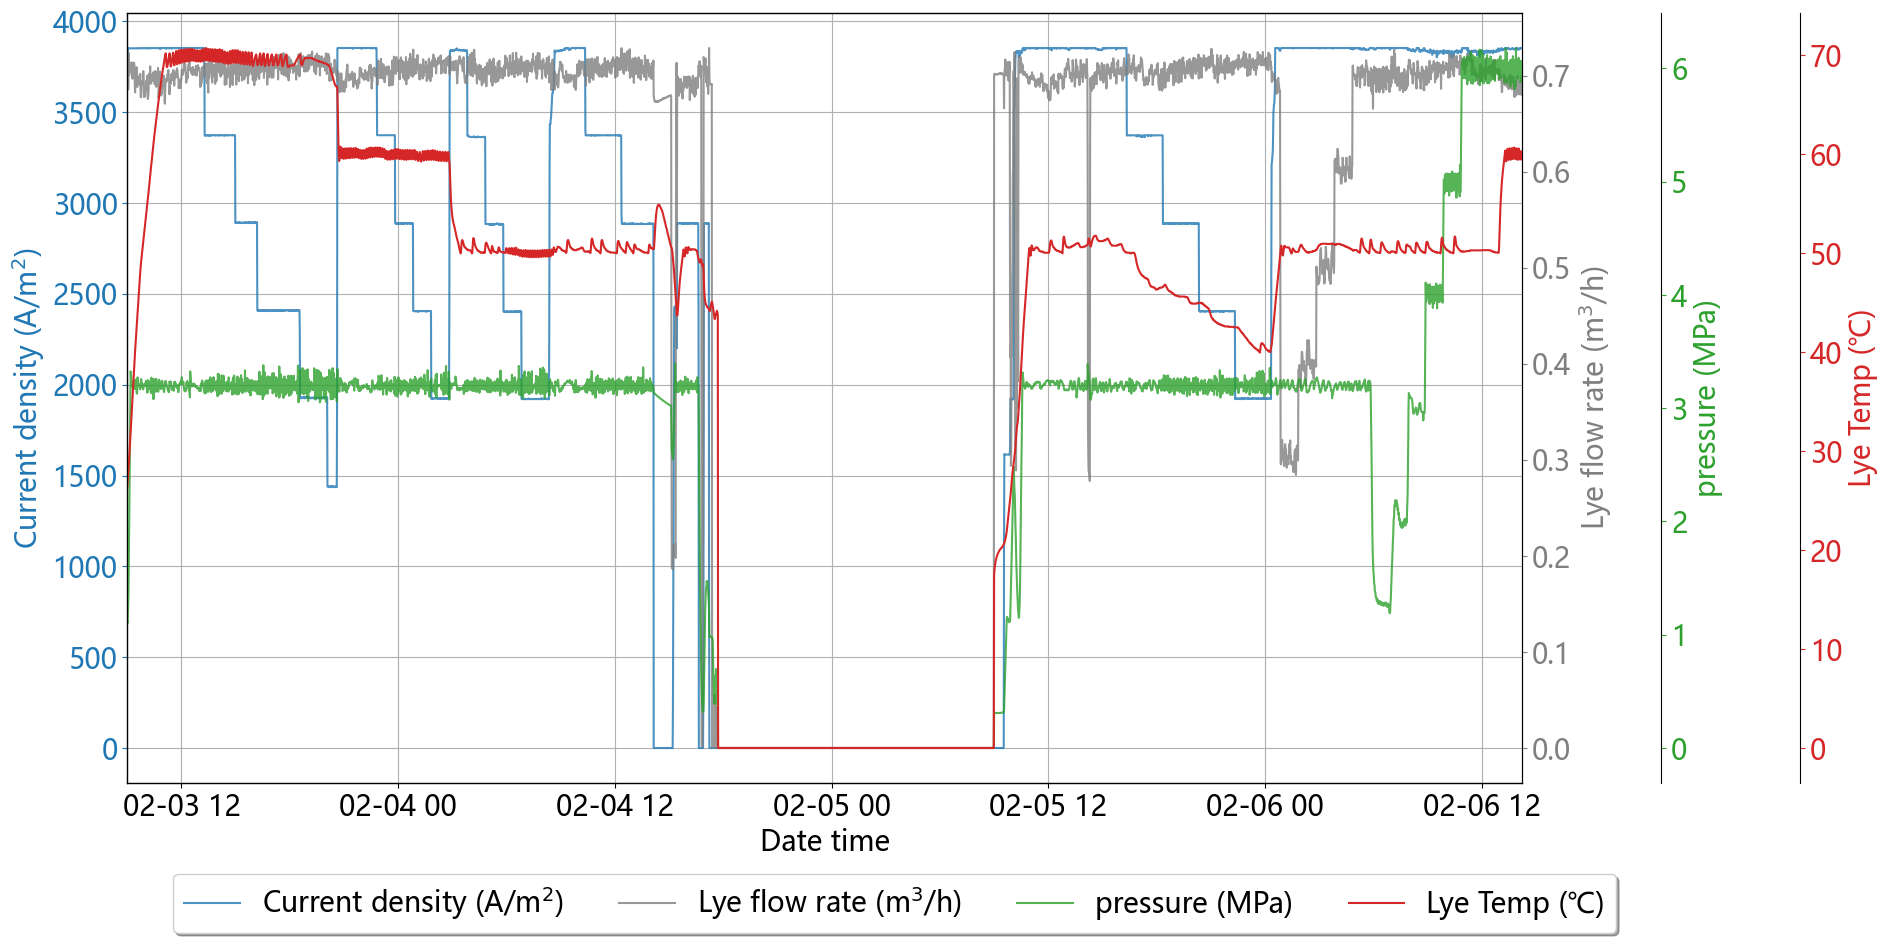

In [12]:
# 创建图表和子图
fig, ax1 = plt.subplots(figsize=(18, 10))
plt.grid(True)

# 绘制碱液流量曲线
ax1.plot(df_Hyzenis[Cols.date_time], df_Hyzenis[Cols.current_density], c = '#1f77b4', alpha = 0.8,label = 'Current density (A/m$^2$)')
ax1.set_ylabel('Current density (A/m$^2$)', color='#1f77b4')
ax1.margins(x=0)  # 仅消除x轴边距
ax1.set_xlabel('Date time')
ax1.tick_params('y', colors='#1f77b4')
# ax1.set_ylim((1800, 4800))

# 创建第二个y轴
ax2 = ax1.twinx()

# 绘制第电流曲线
ax2.plot(df_Hyzenis[Cols.date_time], df_Hyzenis[Cols.lye_flow], alpha=0.8, c = '#7f7f7f', label = 'Lye flow rate (m$^3$/h)')
ax2.set_ylabel('Lye flow rate (m$^3$/h)', color='#7f7f7f')
ax2.tick_params('y', colors='#7f7f7f')
# ax2.set_ylim(0.2, 1.0)


# 创建第三个y轴
ax3 = ax1.twinx()

# 绘制电压曲线
ax3.plot(df_Hyzenis[Cols.date_time],df_Hyzenis[Cols.pressure], c = '#2ca02c', alpha = 0.8,label = 'pressure (MPa)')
ax3.set_ylabel('pressure (MPa)', color='#2ca02c')
ax3.spines['right'].set_position(('outward', 100))
ax3.tick_params('y', colors='#2ca02c')
# ax3.set_ylim((1.7, 2.1))


# 创建第四个y轴
ax4 = ax1.twinx()

# 绘制出口温度曲线
ax4.plot(df_Hyzenis[Cols.date_time],df_Hyzenis[Cols.lye_temp], c = '#d62728', label = 'Lye Temp (℃)')
ax4.set_xlabel('Date time')
ax4.set_ylabel('Lye Temp (℃)', color='#d62728')
ax4.spines['right'].set_position(('outward', 200))
ax4.tick_params('y', colors='#d62728')
# ax4.set_ylim(30, 105)


# 添加图例
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax1.legend(lines + lines2 + lines3 + lines4, labels + labels2 + labels3 + labels4, loc='upper center',
           bbox_to_anchor=(0.55, -0.1), ncol=4, frameon=True, fancybox=True, shadow=True, fontsize=20)

# 显示图表
plt.show()

In [14]:
# 两个时间段分别筛选
start_1, end_1 = '2026-02-03 12:00:00', '2026-02-04 12:00:00'
start_2, end_2 = '2026-02-05 12:00:00', '2026-02-06 12:00:00'

df_Hyzenis_01 = df_Hyzenis.query(
    f"@start_1 < {Cols.date_time} < @end_1"
).copy()

df_Hyzenis_02 = df_Hyzenis.query(
    f"@start_2 < {Cols.date_time} < @end_2"
).copy()

In [15]:
# 碱液流量进行平滑处理
df_Hyzenis_preprocessed_01 = df_Hyzenis_01.copy()
df_Hyzenis_preprocessed_02 = df_Hyzenis_02.copy()

df_Hyzenis_preprocessed_01[Cols.lye_flow] = df_Hyzenis_preprocessed_01[Cols.lye_flow].rolling(window=10, min_periods=10, center=True).mean()
df_Hyzenis_preprocessed_02[Cols.lye_flow] = df_Hyzenis_preprocessed_02[Cols.lye_flow].rolling(window=10, min_periods=10, center=True).mean()

### 选取稳态点

In [16]:
# 计算前后 5min 的氧中氢极差，筛选出极差小于 0.2 的行
window_size = 5
df_Hyzenis_preprocessed_chosen_01 = df_Hyzenis_preprocessed_01[
    df_Hyzenis_preprocessed_01[Cols.temp_out].rolling(window=window_size, center=True, min_periods=1).apply(lambda x: x.max() - x.min()) < 0.2
    ].copy()
df_Hyzenis_preprocessed_chosen_02 = df_Hyzenis_preprocessed_02[
    df_Hyzenis_preprocessed_02[Cols.temp_out].rolling(window=window_size, center=True, min_periods=1).apply(lambda x: x.max() - x.min()) < 0.2
    ].copy()

In [17]:
# 按行合并并重置索引
df_Hyzenis_processed = pd.concat([df_Hyzenis_preprocessed_chosen_01, df_Hyzenis_preprocessed_chosen_02], axis=0, ignore_index=True)

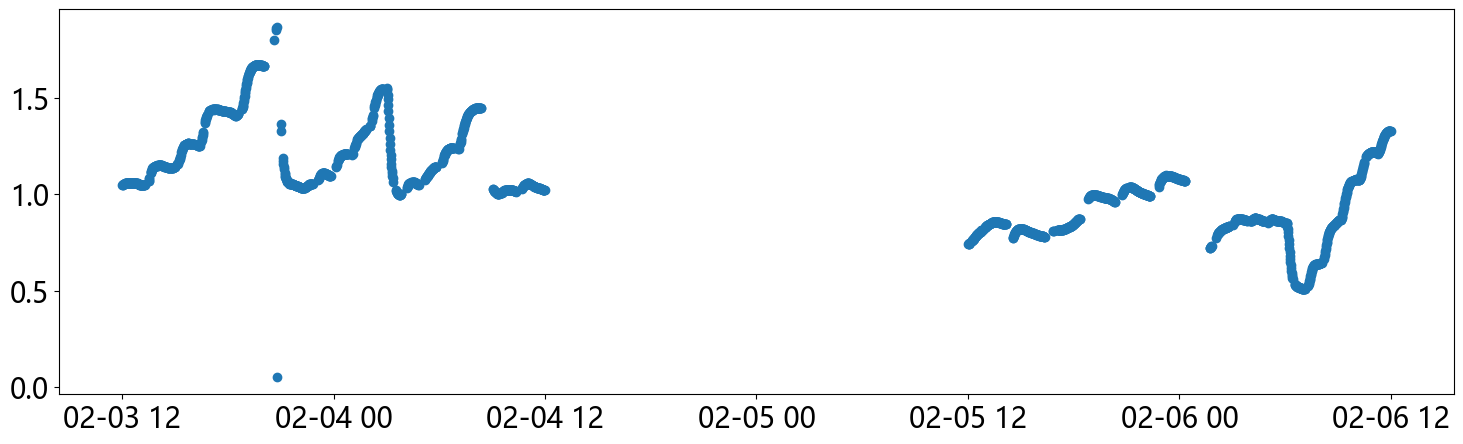

In [18]:
plt.figure(figsize=(18, 5))
plt.scatter(df_Hyzenis_processed[Cols.date_time], df_Hyzenis_processed[Cols.HTO])

## 构建纯度计算公式

In [19]:
Faraday_constant = 96485  # 法拉第常数，单位C/mol
S_H2_KOH = 0.088  # 氢在碱液中的溶解度，单位mol/m3
S_O2_KOH = 0.088  # 氧在碱液中的溶解度，单位mol/m3

Diameter_Electrode = 560 * 1E-3  # 电极直径，单位m
Area_Electrode = math.pi * (Diameter_Electrode / 2) ** 2  # 电极面积，单位m2
Num_Cells = 31  # 电池数量

In [27]:
feature_cols = [Cols.current_density, Cols.pressure_H_cat, Cols.pressure_O_ano, Cols.lye_temp, Cols.temp_H, Cols.temp_O, Cols.lye_flow]
target_cols = [Cols.HTO, Cols.OTH]

statistics = df_Hyzenis_processed[feature_cols]
cell_voltage_observed = df_Hyzenis_processed[target_cols]

In [28]:
# 拟合前准备：张量构造与可微计算函数定义
torch.manual_seed(42)

# 构造训练张量
x = torch.tensor(statistics.values, dtype=torch.float32)
y = torch.tensor(cell_voltage_observed.values, dtype=torch.float32)

# 去除缺失值行
valid_mask = torch.isfinite(x).all(dim=1) & torch.isfinite(y).all(dim=1)
x = x[valid_mask]
y = y[valid_mask]

# 拆分输入特征
current_density = x[:, 0]
P_H_cat_raw = x[:, 1]
P_O_ano_raw = x[:, 2]
lye_temp = x[:, 3]
temp_H = x[:, 4]
temp_O = x[:, 5]
lye_flow = x[:, 6]

def p_h2o_cal_torch(T):
    # 饱和水蒸气压，单位 MPa
    return 0.61078 * torch.exp((17.27 * T) / (T + 237.3)) / 1000.0

def empirical_faraday_efficiency_torch(current_density, temp_out, lye_temp):
    temp_work = (temp_out + lye_temp) / 2.0
    return (current_density ** 2 / (1.067e4 + 101.1 * temp_work + current_density ** 2)) * (0.989 + 7.641e-5 * temp_work) * 0.97

def hto_oth_cal_torch(a1, a2, b1, b2):
    P_H_cat = P_H_cat_raw - p_h2o_cal_torch(temp_H)
    P_O_ano = P_O_ano_raw - p_h2o_cal_torch(temp_O)
    delta_P = P_O_ano - P_H_cat

    nH2 = (S_H2_KOH * P_H_cat * lye_flow) / 4.0 + a1 * S_H2_KOH * P_H_cat + a2 * S_H2_KOH * P_H_cat * delta_P
    nO2 = (S_O2_KOH * P_O_ano * lye_flow) / 4.0 + b1 * S_O2_KOH * P_O_ano + b2 * S_O2_KOH * P_O_ano * delta_P

    temp_out = (temp_H + temp_O) / 2.0
    yita_faraday = empirical_faraday_efficiency_torch(current_density, temp_out, lye_temp)
    ndot_H2 = yita_faraday * current_density * Area_Electrode * Num_Cells * 3600.0 / Faraday_constant / 2.0 * 22.4 * 1e-3
    ndot_O2 = ndot_H2 / 2.0

    eps = 1e-8
    HTO = ndot_H2 / (nO2 - ndot_O2 + ndot_H2 + eps)
    OTH = ndot_O2 / (nH2 - ndot_H2 + ndot_O2 + eps)

    pred = torch.stack([HTO, OTH], dim=1)
    return pred

In [29]:
# 训练单元：使用梯度下降拟合 a1, a2, b1, b2

# 待拟合参数
a1 = torch.nn.Parameter(torch.tensor(0.1, dtype=torch.float32))
a2 = torch.nn.Parameter(torch.tensor(0.1, dtype=torch.float32))
b1 = torch.nn.Parameter(torch.tensor(0.1, dtype=torch.float32))
b2 = torch.nn.Parameter(torch.tensor(0.1, dtype=torch.float32))

optimizer = torch.optim.Adam([a1, a2, b1, b2], lr=1e-2)
num_epochs = 4000

for epoch in range(num_epochs):
    optimizer.zero_grad()
    pred = hto_oth_cal_torch(a1, a2, b1, b2)

    # 仅保留有效预测样本
    valid_pred_mask = torch.isfinite(pred).all(dim=1)
    pred_valid = pred[valid_pred_mask]
    y_valid = y[valid_pred_mask]

    loss = torch.mean((pred_valid - y_valid) ** 2)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.8f}")

print("\nFitted coefficients:")
print(f"a1 = {a1.item():.8f}")
print(f"a2 = {a2.item():.8f}")
print(f"b1 = {b1.item():.8f}")
print(f"b2 = {b2.item():.8f}")

with torch.no_grad():
    pred_all = hto_oth_cal_torch(a1, a2, b1, b2)
    valid_pred_mask = torch.isfinite(pred_all).all(dim=1)
    y_eval = y[valid_pred_mask]
    pred_eval = pred_all[valid_pred_mask]
    mse_hto = torch.mean((pred_eval[:, 0] - y_eval[:, 0]) ** 2).item()
    mse_oth = torch.mean((pred_eval[:, 1] - y_eval[:, 1]) ** 2).item()

print(f"MSE(HTO) = {mse_hto:.8f}")
print(f"MSE(OTH) = {mse_oth:.8f}")

Epoch [500/4000], Loss: 0.77345616
Epoch [1000/4000], Loss: 0.61260492
Epoch [1500/4000], Loss: 0.51111609
Epoch [2000/4000], Loss: 0.44078660
Epoch [2500/4000], Loss: 0.38906145
Epoch [3000/4000], Loss: 0.34943792
Epoch [3500/4000], Loss: 0.31818125
Epoch [4000/4000], Loss: 0.29297137

Fitted coefficients:
a1 = -28.17020035
a2 = -28.65101433
b1 = 21.95336914
b2 = 23.65936852
MSE(HTO) = 0.16188942
MSE(OTH) = 0.42396230


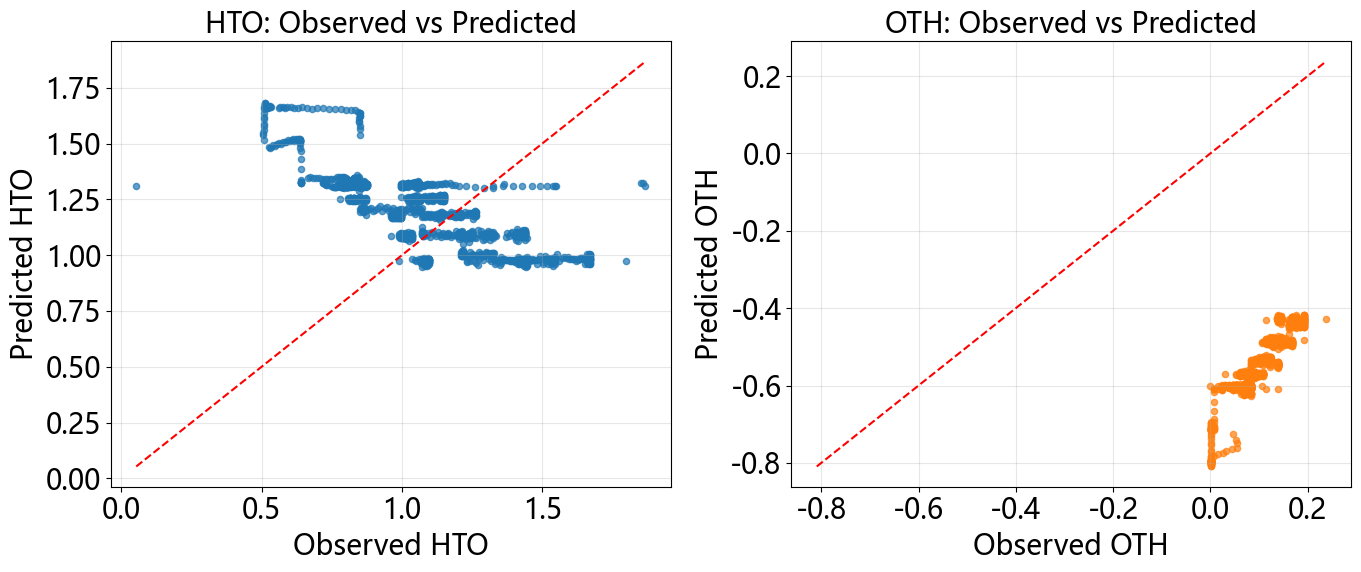

In [30]:
# 可视化单元：实测值与预测值对比
with torch.no_grad():
    pred_all = hto_oth_cal_torch(a1, a2, b1, b2)
    valid_pred_mask = torch.isfinite(pred_all).all(dim=1)
    y_eval = y[valid_pred_mask].cpu().numpy()
    pred_eval = pred_all[valid_pred_mask].cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# HTO 对比
axes[0].scatter(y_eval[:, 0], pred_eval[:, 0], alpha=0.7, s=20)
min_hto = min(y_eval[:, 0].min(), pred_eval[:, 0].min())
max_hto = max(y_eval[:, 0].max(), pred_eval[:, 0].max())
axes[0].plot([min_hto, max_hto], [min_hto, max_hto], 'r--', linewidth=1.5)
axes[0].set_title('HTO: Observed vs Predicted')
axes[0].set_xlabel('Observed HTO')
axes[0].set_ylabel('Predicted HTO')
axes[0].grid(True, alpha=0.3)

# OTH 对比
axes[1].scatter(y_eval[:, 1], pred_eval[:, 1], alpha=0.7, s=20, color='#ff7f0e')
min_oth = min(y_eval[:, 1].min(), pred_eval[:, 1].min())
max_oth = max(y_eval[:, 1].max(), pred_eval[:, 1].max())
axes[1].plot([min_oth, max_oth], [min_oth, max_oth], 'r--', linewidth=1.5)
axes[1].set_title('OTH: Observed vs Predicted')
axes[1].set_xlabel('Observed OTH')
axes[1].set_ylabel('Predicted OTH')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()